<a href="https://colab.research.google.com/github/mohnishjason12/Stock-Market-Price-Prediction/blob/main/SMP_using_SR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Linear Regression Metrics ---
MAE: 4.0121918630784466
RMSE: 5.052189506800053
R² Score: 0.9960328272849182

--- Polynomial Regression Metrics ---
MAE: 109.24718641303662
RMSE: 117.42100307678851
R² Score: -1.142956796468963


/tmp/ipython-input-351729555.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, progress=False)


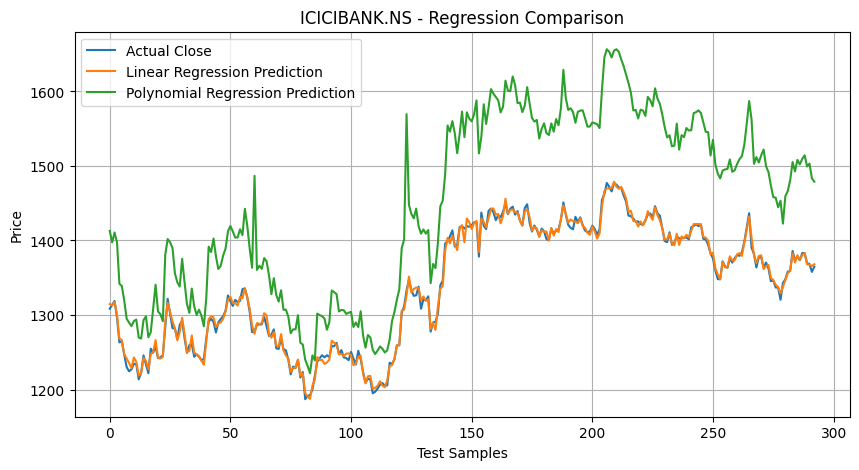


 Predicted NEXT DAY OPEN PRICE for ICICIBANK.NS: ₹1368.04


In [9]:
# Enhanced Linear Regression Stock Prediction with Next-Day OPEN Price Forecast
# Requirements:
# pip install yfinance pandas numpy scikit-learn matplotlib

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# -------- SETTINGS ---------
TICKER = "ICICIBANK.NS"
START_DATE = "2020-01-01"
# ---------------------------

def load_data(ticker, start):
    df = yf.download(ticker, start=start, progress=False)
    if df.empty:
        raise ValueError("Failed to download data.")
    return df[["Open", "High", "Low", "Close", "Volume"]].dropna()

def main():
    print(f"Downloading {TICKER}...")
    df = load_data(TICKER, START_DATE)

    # Add previous day close as a feature
    df["Prev_Close"] = df["Close"].shift(1)
    df.dropna(inplace=True)

    # Features (X) and Target (y)
    X = df[["Prev_Close", "Open", "High", "Low", "Volume"]]
    y = df["Close"]   # Predicting CLOSE for test evaluation

    # Train-test split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # ---------------- LINEAR REGRESSION ----------------
    lin_model = LinearRegression()
    lin_model.fit(X_train, y_train)

    lin_pred = lin_model.predict(X_test)

    # ---------------- POLYNOMIAL REGRESSION ----------------
    poly = PolynomialFeatures(degree=2)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)

    poly_model = LinearRegression()
    poly_model.fit(X_poly_train, y_train)

    poly_pred = poly_model.predict(X_poly_test)

    # ---------------- Evaluation ----------------
    print("\n--- Linear Regression Metrics ---")
    print("MAE:", mean_absolute_error(y_test, lin_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, lin_pred)))
    print("R² Score:", r2_score(y_test, lin_pred))

    print("\n--- Polynomial Regression Metrics ---")
    print("MAE:", mean_absolute_error(y_test, poly_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, poly_pred)))
    print("R² Score:", r2_score(y_test, poly_pred))

    # ---------------- Plotting ----------------
    plt.figure(figsize=(10, 5))
    plt.plot(y_test.values, label="Actual Close")
    plt.plot(lin_pred, label="Linear Regression Prediction")
    plt.plot(poly_pred, label="Polynomial Regression Prediction")
    plt.title(f"{TICKER} - Regression Comparison")
    plt.xlabel("Test Samples")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------------- Predict Next Day OPEN Price ----------------
    last_row = df.iloc[-1]

    # Extract the same features used for training and reshape for single sample prediction
    features_for_prediction = last_row[["Prev_Close", "Open", "High", "Low", "Volume"]]
    next_input = features_for_prediction.to_numpy().reshape(1, -1)

    # Predicting NEXT-DAY OPEN using Linear Regression
    next_day_open_pred = lin_model.predict(next_input)[0].item()

    print("\n==========================================")
    print(f" Predicted NEXT DAY OPEN PRICE for {TICKER}: ₹{next_day_open_pred:.2f}")
    print("==========================================")

if __name__ == "__main__":
    main()
